2026-03-02 01:37:17.861 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-02 01:37:17.863 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-02 01:37:18.520 
  command:

    streamlit run c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-02 01:37:18.520 No runtime found, using MemoryCacheStorageManager
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


(899, 12)
Index(['Year', 'Province', 'District', 'Latitude', 'Longitude', 'Elevation',
       'Month', 'Cases', 'Temp_avg', 'Precipitation_avg', 'Humidity_avg',
       'Population'],
      dtype='object')
   Year Province  District  Latitude  Longitude  Elevation  Month  Cases  \
0  2019  Western   Colombo  6.924429   79.90725          4      1   1225   
1  2019  Western   Gampaha  7.065026   79.96622         19      1    724   
2  2019  Western  Kalutara  6.572935   80.02519          5      1    372   
3  2019  Central     Kandy  7.275923   80.62659        499      1    288   
4  2019  Central    Matale  7.486819   80.52632        362      1     62   

    Temp_avg  Precipitation_avg  Humidity_avg  Population  
0  26.914286           0.771429     72.607143   6149000.0  
1  27.417857           0.728571     69.892857   6149000.0  
2  26.112500           1.396429     80.464286   6149000.0  
3  22.067857           1.853571     83.428571   2766000.0  
4  25.592857           0.850000     74

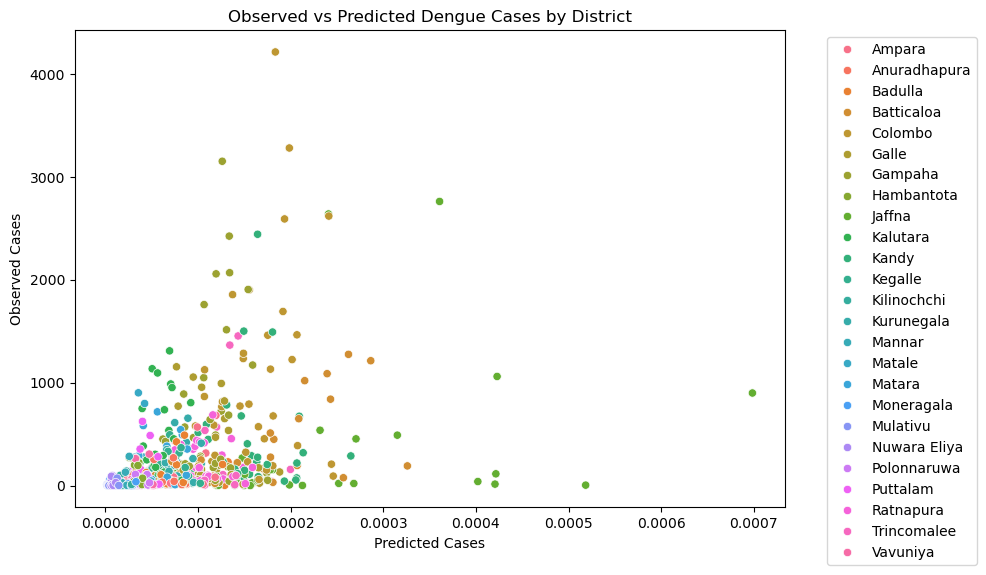

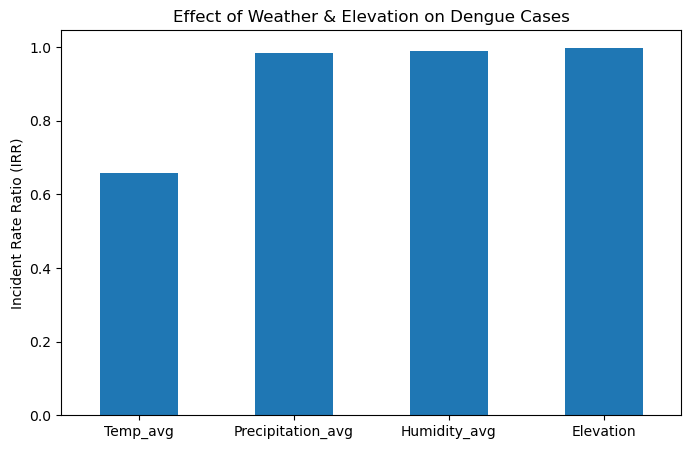

Negative Binomial Residual Deviance / DF: 1.4769709001746654


In [ ]:
# ============================
# DENGUE ANALYSIS FROM SCRATCH
# ============================

# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from components import data_loader


# Step 1: Load Dataset
#df = pd.read_csv("dengue_data_with_weather_data.csv")
df_raw = data_loader.load_dengue_data()
df = data_loader.preprocess_data(df_raw)

# Step 2: Quick Look
print(df.shape)
print(df.columns)
print(df.head())

# Step 3: Data Cleaning
# Drop missing values
df = df.dropna()

# Ensure correct types
df['District'] = df['District'].astype('category')
df['Province'] = df['Province'].astype('category')
df['Month'] = df['Month'].astype(int)
df['Year'] = df['Year'].astype(int)

# Step 4: Add Population Data (per Province)
population = {
    'Western': 6149000,
    'Central': 2766000,
    'Southern': 2654000,
    'Northern': 1143000,
    'Eastern': 1729000,
    'North Western': 2551000,
    'North central': 1377000,
    'Uva': 1376000,
    'Sabaragamuwa': 2058000
}

df['Population'] = df['Province'].map(population)

# Step 5: Exploratory Checks
print("Minimum Cases:", df['Cases'].min())
print("Mean Cases:", df['Cases'].mean())
print("Variance Cases:", df['Cases'].var())
dispersion_ratio = df['Cases'].var() / df['Cases'].mean()
print("Dispersion Ratio (Variance / Mean):", dispersion_ratio)

# Step 6: Fit Simple Poisson Model (just for comparison)
poisson_model = smf.glm(
    formula="Cases ~ Temp_avg + Precipitation_avg + Humidity_avg + Elevation",
    data=df,
    family=sm.families.Poisson()
).fit()
#print(poisson_model.summary())

# Check overdispersion
resid_dev = poisson_model.deviance
df_resid = poisson_model.df_resid
dispersion_stat = resid_dev / df_resid
print("Poisson Residual Deviance / DF:", dispersion_stat)

if dispersion_stat > 1.5:
    print("Evidence of overdispersion → Negative Binomial recommended")
elif dispersion_stat < 0.8:
    print("Possible underdispersion")
else:
    print("Poisson assumption reasonably satisfied")

# Step 7: Fit Strong Negative Binomial Model
# Ensure Population is numeric
df['Population'] = df['Population'].astype(float)

# Fit Negative Binomial model with district fixed effects and population offset
nb_model_strong = smf.glm(
    formula="Cases ~ Temp_avg + Precipitation_avg + Humidity_avg + Elevation + C(District)",
    data=df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(df['Population'])  # log of numeric population
).fit()

print(nb_model_strong.summary())

# Step 8: Extract Incident Rate Ratios (IRR)
irr_strong = np.exp(nb_model_strong.params)
print("\n--- Incident Rate Ratios ---")
print(irr_strong)

# Step 9: Predicted Cases
df['Predicted_Cases'] = nb_model_strong.predict(df)

# ============================
# Step 10: Plots for Exploration
# ============================

# Plot 1: Observed vs Predicted Cases per District
plt.figure(figsize=(10,6))
sns.scatterplot(x='Predicted_Cases', y='Cases', hue='District', data=df)
plt.xlabel("Predicted Cases")
plt.ylabel("Observed Cases")
plt.title("Observed vs Predicted Dengue Cases by District")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: IRR of Weather & Elevation Variables
irr_vars = irr_strong[['Temp_avg','Precipitation_avg','Humidity_avg','Elevation']]
plt.figure(figsize=(8,5))
irr_vars.plot(kind='bar')
plt.ylabel("Incident Rate Ratio (IRR)")
plt.title("Effect of Weather & Elevation on Dengue Cases")
plt.xticks(rotation=0)
plt.show()

# ============================
# Step 11: Optional — Check Residual Deviance / DF
# ============================
resid_dev_nb = nb_model_strong.deviance
df_resid_nb = nb_model_strong.df_resid
dispersion_stat_nb = resid_dev_nb / df_resid_nb
print("Negative Binomial Residual Deviance / DF:", dispersion_stat_nb)

In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("dengue_data_with_weather_data.csv")

# Compute mean and variance of cases
mean_cases = df["Cases"].mean()
var_cases = df["Cases"].var()

print("Mean of Cases:", mean_cases)
print("Variance of Cases:", var_cases)

if var_cases > mean_cases:
    print("Variance exceeds mean → Possible overdispersion")
else:
    print("Variance roughly equal to mean → Poisson assumption plausible")

Mean of Cases: 190.2577777777778
Variance of Cases: 165941.884533432
Variance exceeds mean → Possible overdispersion


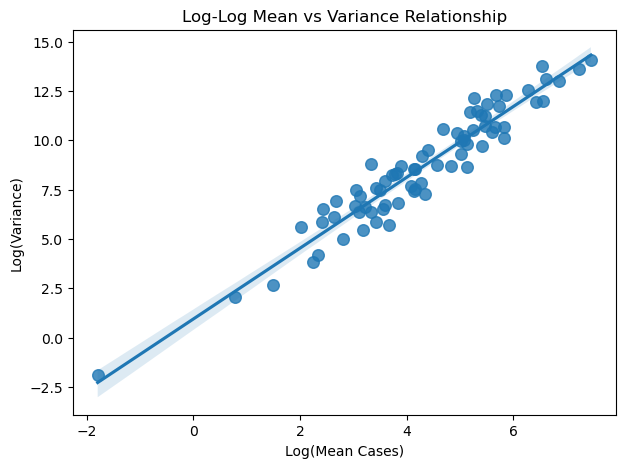

                            OLS Regression Results                            
Dep. Variable:                log_var   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     808.7
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           6.91e-41
Time:                        22:37:55   Log-Likelihood:                -91.566
No. Observations:                  74   AIC:                             187.1
Df Residuals:                      72   BIC:                             191.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9387      0.289      3.243      0.0

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Group data to compute mean and variance per district-year
group_stats = df.groupby(["District","Year"])["Cases"].agg(["mean","var"]).reset_index()

# Remove zero values to avoid log problems
group_stats = group_stats[(group_stats["mean"] > 0) & (group_stats["var"] > 0)]

# Log transformation
group_stats["log_mean"] = np.log(group_stats["mean"])
group_stats["log_var"] = np.log(group_stats["var"])

# Plot log-log relationship
plt.figure(figsize=(7,5))
sns.regplot(x="log_mean", y="log_var", data=group_stats, scatter_kws={"s":70})
plt.xlabel("Log(Mean Cases)")
plt.ylabel("Log(Variance)")
plt.title("Log-Log Mean vs Variance Relationship")
plt.show()

X = sm.add_constant(group_stats["log_mean"])
y = group_stats["log_var"]

log_model = sm.OLS(y, X).fit()

print(log_model.summary())

In [5]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Fit Poisson model
poisson_model = smf.glm(
    formula="Cases ~ Temp_avg + Precipitation_avg + Humidity_avg",
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

resid_dev = poisson_model.deviance
df_resid = poisson_model.df_resid

dispersion_stat = resid_dev / df_resid

print("Poisson Residual Deviance / DF:", dispersion_stat)

if dispersion_stat > 1.5:
    print("Evidence of overdispersion → Negative Binomial recommended")
elif dispersion_stat < 0.8:
    print("Possible underdispersion")
else:
    print("Poisson assumption reasonably satisfied")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Cases   No. Observations:                  899
Model:                            GLM   Df Residuals:                      895
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.6935e+05
Date:                Sun, 08 Mar 2026   Deviance:                   3.3372e+05
Time:                        22:39:20   Pearson chi2:                 5.83e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -8.0192      0.08